<a href="https://colab.research.google.com/github/priyansh-commits/Deep_Learning/blob/main/earlystopping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
from pylab import rcParams
import matplotlib.pyplot as plt
import warnings
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import seaborn as sns

In [2]:
X, y = make_circles(n_samples=1000, noise=0.1, random_state=1)
X


array([[ 0.92787748, -0.04521731],
       [-0.54303182, -0.75444674],
       [ 0.9246533 , -0.71492522],
       ...,
       [ 0.30720657, -0.63102334],
       [-0.92836187,  0.06693357],
       [ 1.03502248,  0.54878286]])

In [3]:
df=pd.DataFrame(X,columns=['x1','x2'])
df['y']=y
df.head()

,x1,x2,y
0,0.927877,-0.045217,1
1,-0.543032,-0.754447,1
2,0.924653,-0.714925,0
3,-0.102171,-0.892835,0
4,-1.017192,0.247378,0


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=2)

In [32]:
model=Sequential()
model.add(Dense(16, input_dim=2, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
# history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=600, verbose=0)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
# plt.plot(history.history['loss'], label='train')
# plt.plot(history.history['val_loss'], label='test')
# plt.legend()
# plt.show()

In [33]:
callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.00001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=True
)

Epoch 1/1500
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.5250 - loss: 0.6930 - val_accuracy: 0.4550 - val_loss: 0.6962
Epoch 2/1500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4963 - loss: 0.6909 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 3/1500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5225 - loss: 0.6887 - val_accuracy: 0.5250 - val_loss: 0.6926
Epoch 4/1500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5575 - loss: 0.6864 - val_accuracy: 0.5350 - val_loss: 0.6894
Epoch 5/1500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5900 - loss: 0.6841 - val_accuracy: 0.5600 - val_loss: 0.6877
Epoch 6/1500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5450 - loss: 0.6816 - val_accuracy: 0.5200 - val_loss: 0.6836
Epoch 7/1500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5962 - loss: 0.6784 - val_accuracy: 0.6250 - val_loss: 0.6834
Epoch 8/1500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6325 - loss: 0.6751 - val_accuracy: 0

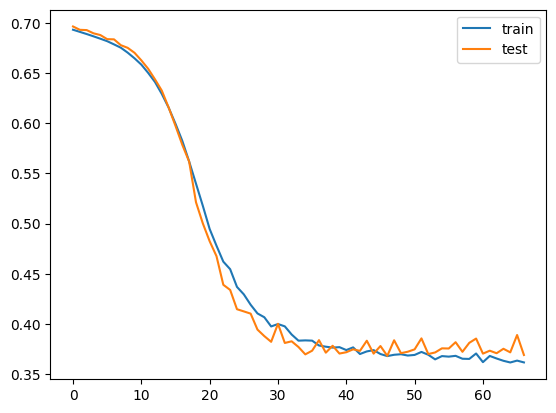

In [34]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=1500, callbacks=callback)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


array([[95, 12],
       [13, 80]])

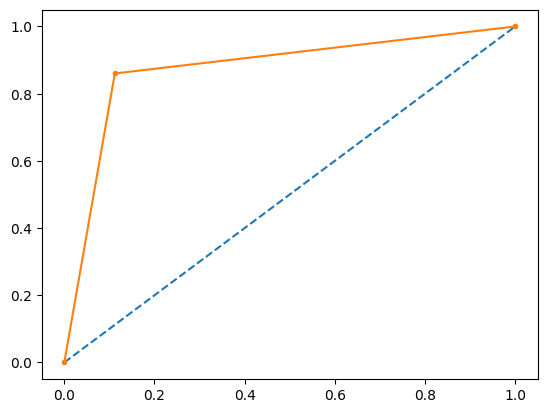

In [35]:
y_prob = model.predict(X_test)
y_prob=y_prob.flatten()
y_prob=np.where(y_prob>0.5,1,0)
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_prob)
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr, tpr, marker='.')
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_prob)
cm

In [36]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.88      0.89      0.88       107
           1       0.87      0.86      0.86        93

    accuracy                           0.88       200
   macro avg       0.87      0.87      0.87       200
weighted avg       0.87      0.88      0.87       200

